In [ ]:
import os
import torch
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git
import torch_geometric.utils
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torch_geometric.datasets import Planetoid
import torch_geometric.transforms as T
import matplotlib.pyplot as plt

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures

dataset = Planetoid(root='data/Planetoid', name='CiteSeer', transform=NormalizeFeatures())

Processing...
Done!


In [ ]:
#вспомогательная функция для визуализации
from sklearn.manifold import TSNE
def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

Выведу характеристики графа.

In [ ]:
print()
print(f'Dataset: {dataset}:')
print('======================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

data = dataset[0]  # Get the first graph object.

print()
print(data)
print('===========================================================================================================')

# Gather some statistics about the graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Number of training nodes: {data.train_mask.sum()}')
print(f'Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')


Dataset: CiteSeer():
Number of graphs: 1
Number of features: 3703
Number of classes: 6

Data(x=[3327, 3703], edge_index=[2, 9104], y=[3327], train_mask=[3327], val_mask=[3327], test_mask=[3327])
Number of nodes: 3327
Number of edges: 9104
Average node degree: 2.74
Number of training nodes: 120
Training node label rate: 0.04
Has isolated nodes: True
Has self-loops: False
Is undirected: True


Использую GAT-слои из torch_geometric.

In [ ]:
class GAT(torch.nn.Module):
    def __init__(self):
        super(GAT, self).__init__()
        self.hid = 8
        self.in_head = 8
        self.out_head = 1

        self.conv1 = GATConv(dataset.num_features, self.hid, heads=self.in_head, dropout=0.6)
        self.conv2 = GATConv(self.hid*self.in_head, dataset.num_classes, concat=False,
                             heads=self.out_head, dropout=0.6)

    def forward(self, data, adj):
        x, edge_index = data.x, data.edge_index
        x = F.dropout(x, p=0.6, training=self.training)
        #x = self.conv1(x, adj)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.6, training=self.training)
        #x = self.conv2(x, adj)
        x = self.conv2(x, edge_index)

        return F.log_softmax(x, dim=1)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = "cpu"

data = dataset[0].to(device)
adj = torch.squeeze(torch_geometric.utils.to_dense_adj(data.edge_index)) # from edge_index (coo format) to dense adj matrix (naive implementation)

Обучение модели и валидация при различных параметрах learning_rate.

In [ ]:
model = GAT().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.05, weight_decay=5e-4)

model.train()
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    out = model(data, adj)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])

    if epoch%10 == 0:
        print(loss)

    loss.backward()
    optimizer.step()

model.eval()
_, pred = model(data, adj).max(dim=1)
correct = float(pred[data.val_mask].eq(data.y[data.val_mask]).sum().item())
acc = correct / data.val_mask.sum().item()
print('Valid accuracy: {:.4f}'.format(acc))

tensor(1.7936, grad_fn=<NllLossBackward0>)
tensor(1.3013, grad_fn=<NllLossBackward0>)
tensor(1.0278, grad_fn=<NllLossBackward0>)
tensor(0.9725, grad_fn=<NllLossBackward0>)
tensor(0.8325, grad_fn=<NllLossBackward0>)
tensor(0.8264, grad_fn=<NllLossBackward0>)
tensor(0.7435, grad_fn=<NllLossBackward0>)
tensor(0.8249, grad_fn=<NllLossBackward0>)
tensor(0.8547, grad_fn=<NllLossBackward0>)
tensor(0.7388, grad_fn=<NllLossBackward0>)
Valid accuracy: 0.7200


In [ ]:
model = GAT().to(device)
model.train()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

model.train()
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    out = model(data, adj)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])

    if epoch%10 == 0:
        print(loss)

    loss.backward()
    optimizer.step()

model.eval()
_, pred = model(data, adj).max(dim=1)
correct = float(pred[data.val_mask].eq(data.y[data.val_mask]).sum().item())
acc = correct / data.val_mask.sum().item()
print('Valid accuracy: {:.4f}'.format(acc))

tensor(1.7901, grad_fn=<NllLossBackward0>)
tensor(1.7341, grad_fn=<NllLossBackward0>)
tensor(1.6665, grad_fn=<NllLossBackward0>)
tensor(1.5787, grad_fn=<NllLossBackward0>)
tensor(1.5193, grad_fn=<NllLossBackward0>)
tensor(1.3756, grad_fn=<NllLossBackward0>)
tensor(1.2897, grad_fn=<NllLossBackward0>)
tensor(1.1763, grad_fn=<NllLossBackward0>)
tensor(1.1756, grad_fn=<NllLossBackward0>)
tensor(1.0363, grad_fn=<NllLossBackward0>)
Valid accuracy: 0.7000


In [ ]:
model = GAT().to(device)
model.train()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=5e-4)

model.train()
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    out = model(data, adj)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])

    if epoch%10 == 0:
        print(loss)

    loss.backward()
    optimizer.step()

model.eval()
_, pred = model(data, adj).max(dim=1)
correct = float(pred[data.val_mask].eq(data.y[data.val_mask]).sum().item())
acc = correct / data.val_mask.sum().item()
print('Valid accuracy: {:.4f}'.format(acc))

tensor(1.7901, grad_fn=<NllLossBackward0>)
tensor(1.7891, grad_fn=<NllLossBackward0>)
tensor(1.7827, grad_fn=<NllLossBackward0>)
tensor(1.7759, grad_fn=<NllLossBackward0>)
tensor(1.7705, grad_fn=<NllLossBackward0>)
tensor(1.7675, grad_fn=<NllLossBackward0>)
tensor(1.7569, grad_fn=<NllLossBackward0>)
tensor(1.7588, grad_fn=<NllLossBackward0>)
tensor(1.7510, grad_fn=<NllLossBackward0>)
tensor(1.7346, grad_fn=<NllLossBackward0>)
Valid accuracy: 0.7020


Наибольшая accuracy получилась при использовании learning_rate=0.05.

In [ ]:
model = GAT().to(device)
model.train()
optimizer = torch.optim.Adam(model.parameters(), lr=0.05, weight_decay=5e-4)

model.train()
for epoch in range(130):
    model.train()
    optimizer.zero_grad()
    out = model(data, adj)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])

    if epoch%10 == 0:
        print(loss)

    loss.backward()
    optimizer.step()

model.eval()
_, pred = model(data, adj).max(dim=1)
correct = float(pred[data.test_mask].eq(data.y[data.test_mask]).sum().item())
acc = correct / data.test_mask.sum().item()
print('Accuracy: {:.4f}'.format(acc))

tensor(1.7924, grad_fn=<NllLossBackward0>)
tensor(1.4003, grad_fn=<NllLossBackward0>)
tensor(1.0385, grad_fn=<NllLossBackward0>)
tensor(0.7879, grad_fn=<NllLossBackward0>)
tensor(0.8335, grad_fn=<NllLossBackward0>)
tensor(0.7153, grad_fn=<NllLossBackward0>)
tensor(0.7517, grad_fn=<NllLossBackward0>)
tensor(0.8101, grad_fn=<NllLossBackward0>)
tensor(0.7393, grad_fn=<NllLossBackward0>)
tensor(0.8904, grad_fn=<NllLossBackward0>)
tensor(0.7327, grad_fn=<NllLossBackward0>)
tensor(0.7815, grad_fn=<NllLossBackward0>)
tensor(0.8139, grad_fn=<NllLossBackward0>)
Accuracy: 0.6960


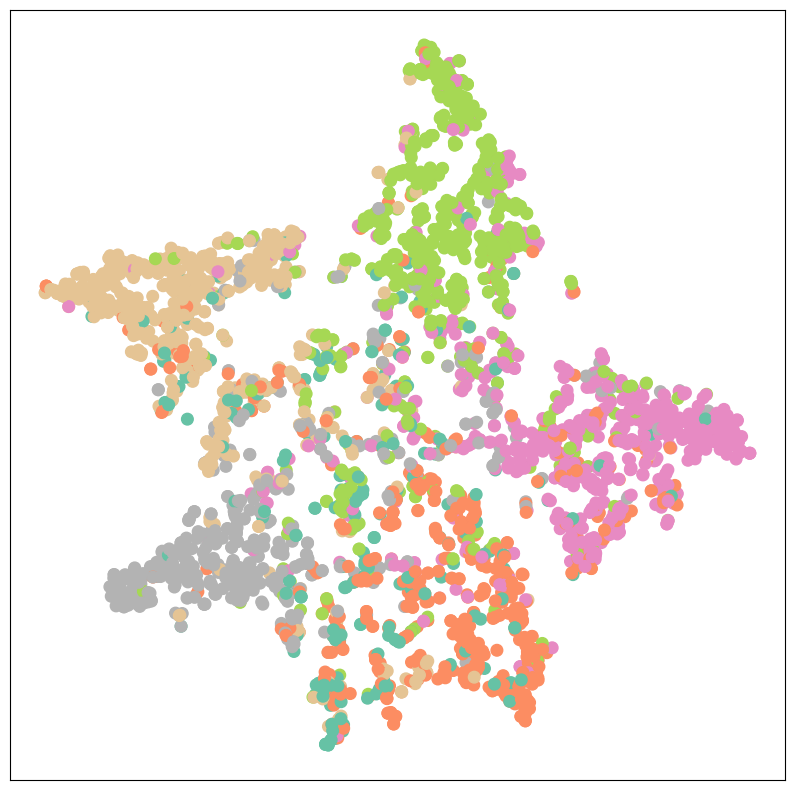

In [ ]:
model.eval()

out = model(data, adj)
visualize(out, color=data.y)

Можно отметить, что результаты получились лучше, чем в предыдущей работе при использовании GCN (accuracy 0.696 против 0.67).